In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [2]:
df = pd.read_csv('pima_diabetes_data.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
#preprocess data
columns_to_process = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

In [7]:
(df[columns_to_process] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [8]:
for column in columns_to_process:
    median_value = df[column].median()
    df[column] = df[column].replace(0, median_value)

In [9]:
(df[columns_to_process] == 0).sum()


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [10]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [11]:
scaler = StandardScaler()

In [12]:
X_scaled = scaler.fit_transform(X)

In [13]:
X_scaled.shape

(768, 8)

In [14]:
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

Text(0, 0.5, 'WCSS')

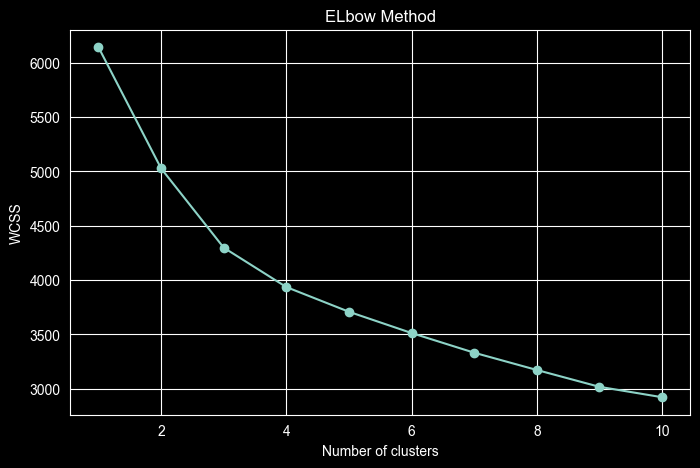

In [15]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('ELbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [16]:
wcss

[6144.000000000001,
 5028.555781256478,
 4298.837235602371,
 3936.018690104692,
 3708.460218345491,
 3512.7890867042515,
 3331.660256250736,
 3172.627701486185,
 3017.606971873515,
 2921.9440893437313]

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)

In [18]:
kmeans_labels = kmeans.fit_predict(X_scaled)

C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [19]:
kmeans_labels

array([2, 1, 2, 1, 0, 1, 1, 2, 0, 2, 2, 2, 2, 0, 2, 1, 0, 1, 1, 1, 0, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 2, 0, 1, 1, 2, 1, 2, 2, 1, 0, 1, 2, 2, 2,
       2, 0, 1, 1, 2, 1, 1, 1, 1, 2, 0, 1, 0, 0, 0, 0, 1, 2, 1, 1, 2, 1,
       1, 2, 1, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 2, 2, 2, 1, 1, 1, 0, 1, 1, 2, 1, 0, 0, 1, 2, 2, 1, 2,
       0, 2, 1, 1, 1, 1, 1, 0, 2, 2, 1, 2, 0, 1, 2, 0, 2, 1, 0, 1, 2, 0,
       2, 0, 1, 1, 1, 2, 2, 2, 0, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 0, 1, 0,
       2, 0, 2, 2, 1, 1, 1, 1, 2, 2, 0, 0, 2, 0, 1, 2, 2, 2, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 2, 1, 2, 2, 1, 2, 1, 0, 2, 0, 2, 0, 0, 1, 1, 2,
       0, 2, 2, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 2, 0, 2, 1, 1, 1,
       1, 1, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 2, 1, 1, 1, 0, 2, 1, 1, 1, 2,
       1, 2, 1, 0, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 2, 2, 2, 2, 2,
       0, 0, 1, 0, 1, 1, 0, 0, 2, 0, 0, 0, 2, 2, 1,

In [20]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels
print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN_Cluster
-1    378
 0    373
 1      8
 2      3
 3      6
Name: count, dtype: int64


In [ ]:
sc